# GMM-UBM Speaker Recognition System
## Complete Pipeline: Training, Evaluation & Visualization

**Architecture:**
1. Load MFCC features (39-dim) exported from our MATLAB from-scratch pipeline
2. Train a **Universal Background Model (UBM)** on ALL speakers pooled together
3. **MAP Adapt** the UBM to each speaker → speaker-specific GMMs
4. **Identify** test utterances by scoring against all speaker GMMs
5. Confidence via softmax over log-likelihood ratios

**MFCC Features:** `13 MFCC + 13 Delta + 13 Delta-Delta = 39 dimensions`

In [2]:
# ============================================================
#  Section 1: Install & Import Required Libraries
# ============================================================
import os
import glob
import pickle
import numpy as np
import scipy.io as sio
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Optional: librosa for audio-based inference
try:
    import librosa
    import librosa.display
    HAS_LIBROSA = True
    print("✓ librosa available (audio-based inference enabled)")
except ImportError:
    HAS_LIBROSA = False
    print("⚠ librosa not found (install with: pip install librosa)")

print("✓ All core libraries loaded successfully!")

✓ librosa available (audio-based inference enabled)
✓ All core libraries loaded successfully!


## Section 2: Configuration

All hyperparameters are centralized here. Key decisions:
- **UBM Components = 16**: Good balance for 8 speakers with ~130 frames each
- **Diagonal Covariance**: Standard for speaker recognition (full needs too much data)
- **MAP Relevance Factor = 16**: Controls adaptation strength (higher = more conservative)

In [3]:
# ============================================================
#  Section 2: Configuration
# ============================================================
class Config:
    # Paths
    EXPORTED_DIR = "exported_features"
    MODEL_DIR = "trained_models"
    
    # GMM-UBM Parameters
    UBM_N_COMPONENTS = 16
    COVARIANCE_TYPE = 'diag'
    UBM_MAX_ITER = 200
    UBM_N_INIT = 3
    
    # MAP Adaptation
    MAP_RELEVANCE_FACTOR = 16.0
    MAP_ADAPT_WEIGHTS = True
    MAP_ADAPT_MEANS = True
    MAP_ADAPT_COVARS = False
    
    # Feature Processing
    USE_FEATURE_SCALING = True
    FEATURE_DIM = 39

config = Config()

print("Configuration Summary:")
print(f"  UBM Components:     {config.UBM_N_COMPONENTS}")
print(f"  Covariance Type:    {config.COVARIANCE_TYPE}")
print(f"  MAP Relevance:      {config.MAP_RELEVANCE_FACTOR}")
print(f"  Feature Dimension:  {config.FEATURE_DIM}")
print(f"  Feature Scaling:    {config.USE_FEATURE_SCALING}")
print(f"  Exported Features:  {config.EXPORTED_DIR}/")
print(f"  Model Directory:    {config.MODEL_DIR}/")

Configuration Summary:
  UBM Components:     16
  Covariance Type:    diag
  MAP Relevance:      16.0
  Feature Dimension:  39
  Feature Scaling:    True
  Exported Features:  exported_features/
  Model Directory:    trained_models/


## Section 3: Load MFCC Features from MATLAB Export

Our MATLAB `export_mfcc_features.m` saves each speaker's MFCCs as `.mat` files:
- `mfcc_coeffs` → (13 × num_frames)  
- `delta_mfcc` → (13 × num_frames)  
- `delta2_mfcc` → (13 × num_frames)

We transpose and stack them → **(num_frames × 39)** for Python.

In [4]:
# ============================================================
#  Section 3: Load MFCC Features
# ============================================================
def load_mfcc_features(data_dir, set_name):
    """Load all MFCC .mat files from exported_features/train or test."""
    mat_dir = os.path.join(data_dir, set_name)
    mat_files = sorted(glob.glob(os.path.join(mat_dir, '*_mfcc.mat')))
    
    if len(mat_files) == 0:
        raise FileNotFoundError(
            f"No .mat files found in '{mat_dir}'.\n"
            f"Run 'export_mfcc_features.m' in MATLAB first!"
        )
    
    speakers_data = {}
    for mat_file in mat_files:
        data = sio.loadmat(mat_file)
        speaker_id = str(data['speaker_id'][0]) if isinstance(data['speaker_id'], np.ndarray) else str(data['speaker_id'])
        
        # MATLAB saves as (coeffs × frames) — transpose to (frames × coeffs) for Python
        if 'mfcc_coeffs' in data and 'delta_mfcc' in data and 'delta2_mfcc' in data:
            mfcc_c = data['mfcc_coeffs'].T
            delta_c = data['delta_mfcc'].T
            delta2_c = data['delta2_mfcc'].T
            features = np.hstack([mfcc_c, delta_c, delta2_c])
        elif 'mfcc_coeffs' in data and 'delta_coeffs' in data and 'delta2_coeffs' in data:
            mfcc_c = data['mfcc_coeffs'].T
            delta_c = data['delta_coeffs'].T
            delta2_c = data['delta2_coeffs'].T
            features = np.hstack([mfcc_c, delta_c, delta2_c])
        else:
            features = data['features']
            if features.shape[0] < features.shape[1]:
                features = features.T
        
        speakers_data[speaker_id] = features
    
    return speakers_data

# Load train and test data
train_data = load_mfcc_features(config.EXPORTED_DIR, 'train')
test_data = load_mfcc_features(config.EXPORTED_DIR, 'test')

# Print summary table
speakers = sorted(set(list(train_data.keys()) + list(test_data.keys())))
print(f"{'Speaker':<10} {'Train Frames':<15} {'Test Frames':<15} {'Dim':<5}")
print("-" * 50)
for spk in speakers:
    tr = train_data.get(spk, np.empty((0, 39)))
    te = test_data.get(spk, np.empty((0, 39)))
    print(f"{spk:<10} {tr.shape[0]:<15} {te.shape[0]:<15} {tr.shape[1]:<5}")
print("-" * 50)
print(f"{'TOTAL':<10} {sum(v.shape[0] for v in train_data.values()):<15} "
      f"{sum(v.shape[0] for v in test_data.values()):<15}")

Speaker    Train Frames    Test Frames     Dim  
--------------------------------------------------
s1         123             123             39   
s2         123             123             39   
s3         123             123             39   
s4         123             123             39   
s5         123             123             39   
s6         123             123             39   
s7         123             123             39   
s8         123             123             39   
--------------------------------------------------
TOTAL      984             984            


## Section 4: Data Exploration & Visualization

Let's see how our data looks:
1. **Frames per speaker** — is the data balanced?
2. **MFCC Heatmap** — what do the 39 features look like over time?

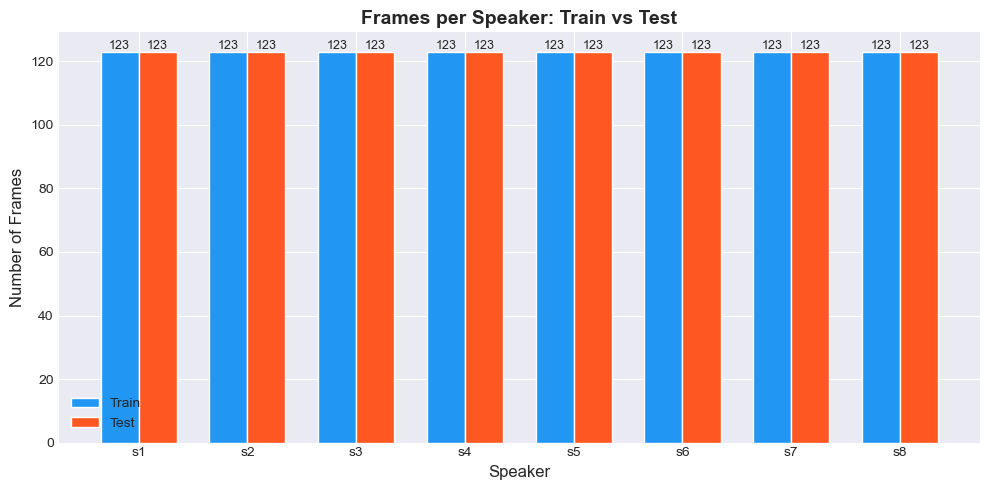

In [5]:
# ============================================================
#  Section 4a: Frames per Speaker (Train vs Test)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(speakers))
width = 0.35
train_counts = [train_data[s].shape[0] for s in speakers]
test_counts = [test_data[s].shape[0] for s in speakers]

bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width/2, test_counts, width, label='Test', color='#FF5722', edgecolor='white')

ax.set_xlabel('Speaker', fontsize=12)
ax.set_ylabel('Number of Frames', fontsize=12)
ax.set_title('Frames per Speaker: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(speakers)
ax.legend()

# Add count labels on bars
for bar in bars1:
    ax.annotate(f'{int(bar.get_height())}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{int(bar.get_height())}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

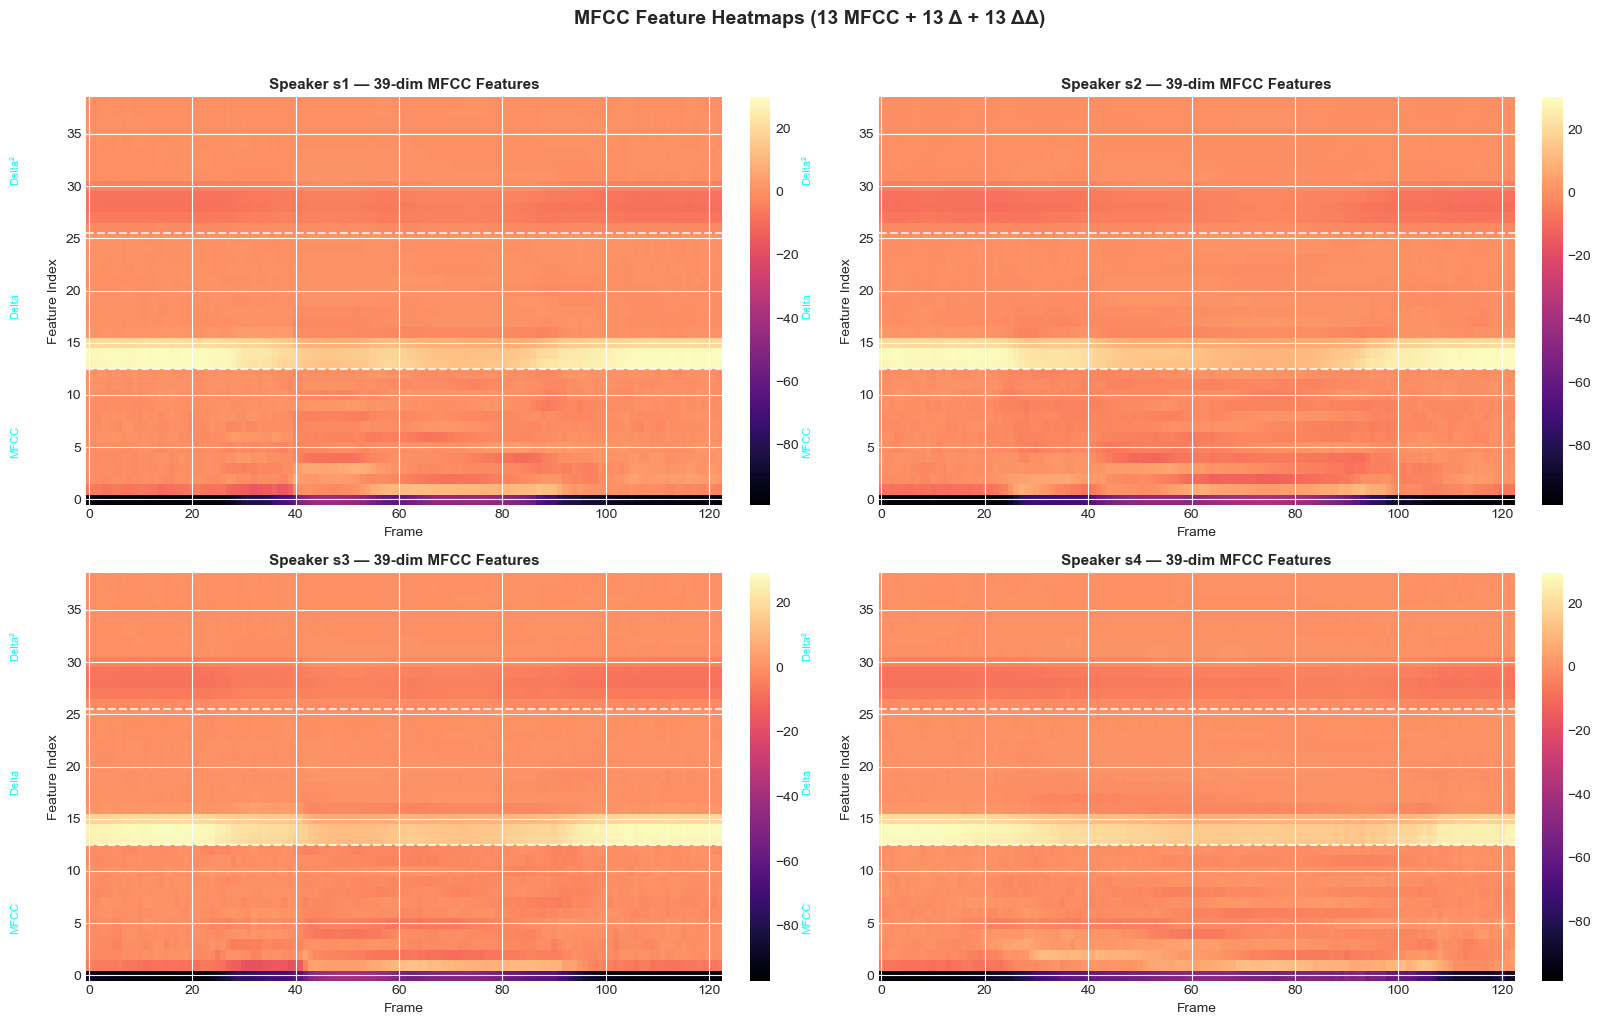

In [6]:
# ============================================================
#  Section 4b: MFCC Feature Heatmap for Sample Speakers
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sample_speakers = speakers[:4]  # First 4 speakers

for ax, spk in zip(axes.flat, sample_speakers):
    features = train_data[spk].T  # (39 × frames) for display
    im = ax.imshow(features, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
    
    # Mark MFCC / Delta / Delta-Delta boundaries
    ax.axhline(y=12.5, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axhline(y=25.5, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'Speaker {spk} — 39-dim MFCC Features', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Feature Index')
    
    # Add region labels
    ax.text(-0.12, 6/39, 'MFCC', transform=ax.transAxes, rotation=90, va='center', fontsize=8, color='cyan')
    ax.text(-0.12, 19/39, 'Delta', transform=ax.transAxes, rotation=90, va='center', fontsize=8, color='cyan')
    ax.text(-0.12, 32/39, 'Delta²', transform=ax.transAxes, rotation=90, va='center', fontsize=8, color='cyan')
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('MFCC Feature Heatmaps (13 MFCC + 13 Δ + 13 ΔΔ)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 5: Feature Distribution per Speaker

Do different speakers produce distinguishable MFCC distributions?  
- **KDE plots** of selected coefficients overlaid across speakers
- **PCA 2D scatter** to see natural clustering in feature space

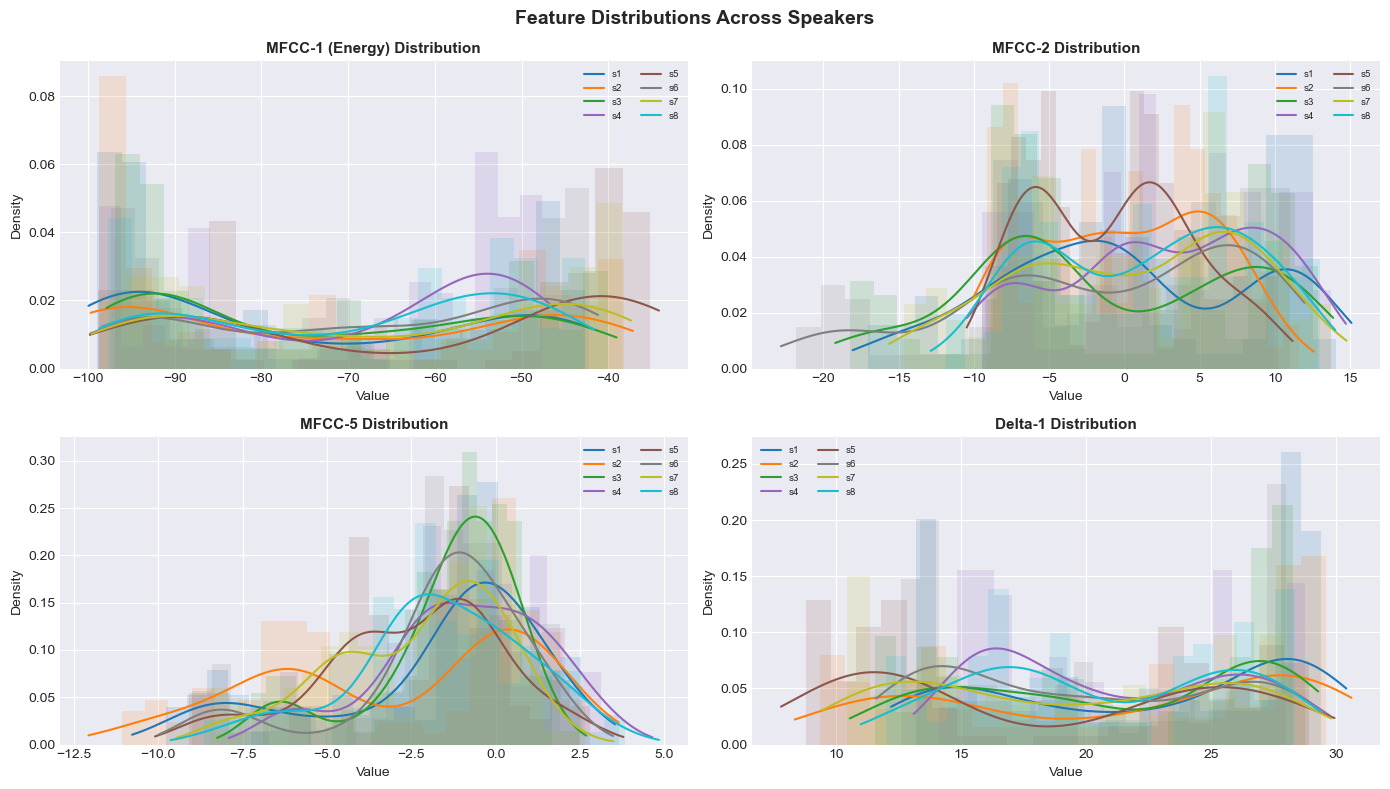

In [7]:
# ============================================================
#  Section 5a: KDE of Selected MFCC Coefficients per Speaker
# ============================================================
coeff_names = ['MFCC-1 (Energy)', 'MFCC-2', 'MFCC-5', 'Delta-1']
coeff_indices = [0, 1, 4, 13]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(speakers)))

for ax, idx, name in zip(axes.flat, coeff_indices, coeff_names):
    for spk, color in zip(speakers, colors):
        data = train_data[spk][:, idx]
        ax.hist(data, bins=20, alpha=0.15, color=color, density=True)
        # KDE
        from scipy.stats import gaussian_kde
        if len(data) > 2:
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min() - 1, data.max() + 1, 200)
            ax.plot(x_range, kde(x_range), color=color, linewidth=1.5, label=spk)
    
    ax.set_title(f'{name} Distribution', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, ncol=2)

fig.suptitle('Feature Distributions Across Speakers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

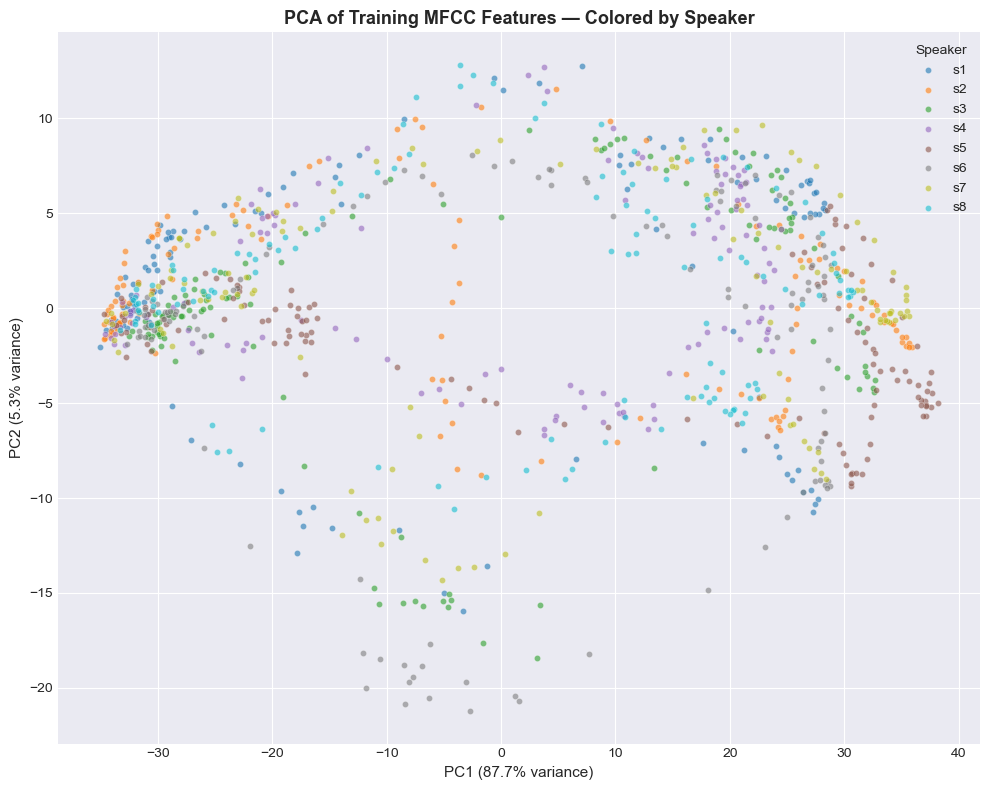

PCA explains 93.0% of total variance in 2 components


In [8]:
# ============================================================
#  Section 5b: PCA 2D Scatter — All Training Frames by Speaker
# ============================================================
all_train_features = np.vstack([train_data[s] for s in speakers])
all_train_labels = np.concatenate([[s] * train_data[s].shape[0] for s in speakers])

pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_train_features)

fig, ax = plt.subplots(figsize=(10, 8))
for spk, color in zip(speakers, colors):
    mask = all_train_labels == spk
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1], 
               c=[color], label=spk, alpha=0.6, s=20, edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('PCA of Training MFCC Features — Colored by Speaker', fontsize=13, fontweight='bold')
ax.legend(title='Speaker', loc='best')
plt.tight_layout()
plt.show()

print(f"PCA explains {pca.explained_variance_ratio_[:2].sum():.1%} of total variance in 2 components")

## Section 6: Train Universal Background Model (UBM)

The UBM captures **"what speech sounds like in general"** by pooling ALL speakers' training data. It's a Gaussian Mixture Model trained on the combined feature space.

$$\text{UBM} = \sum_{k=1}^{K} w_k \cdot \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

In [9]:
# ============================================================
#  Section 6: Train UBM
# ============================================================
# Pool all training data
all_train = np.vstack([train_data[s] for s in speakers])
print(f"Pooled training data: {all_train.shape[0]} frames × {all_train.shape[1]} features")

# Feature scaling
scaler = StandardScaler()
all_train_scaled = scaler.fit_transform(all_train)

# Train UBM
print(f"\nTraining UBM with {config.UBM_N_COMPONENTS} components...")
ubm = GaussianMixture(
    n_components=config.UBM_N_COMPONENTS,
    covariance_type=config.COVARIANCE_TYPE,
    max_iter=config.UBM_MAX_ITER,
    n_init=config.UBM_N_INIT,
    random_state=42,
    verbose=0
)
ubm.fit(all_train_scaled)

print(f"✓ UBM Converged: {ubm.converged_}")
print(f"✓ Log-Likelihood: {ubm.score(all_train_scaled):.2f}")
print(f"✓ BIC: {ubm.bic(all_train_scaled):.0f}")
print(f"✓ AIC: {ubm.aic(all_train_scaled):.0f}")
print(f"✓ Component weights range: [{ubm.weights_.min():.3f}, {ubm.weights_.max():.3f}]")

Pooled training data: 984 frames × 39 features

Training UBM with 16 components...
✓ UBM Converged: True
✓ Log-Likelihood: -24.72
✓ BIC: 57355
✓ AIC: 51177
✓ Component weights range: [0.032, 0.130]


## Section 7: Visualize UBM Components (PCA)

Let's see where the UBM's Gaussian components sit in the 2D PCA space, overlaid on the speaker-colored training data.

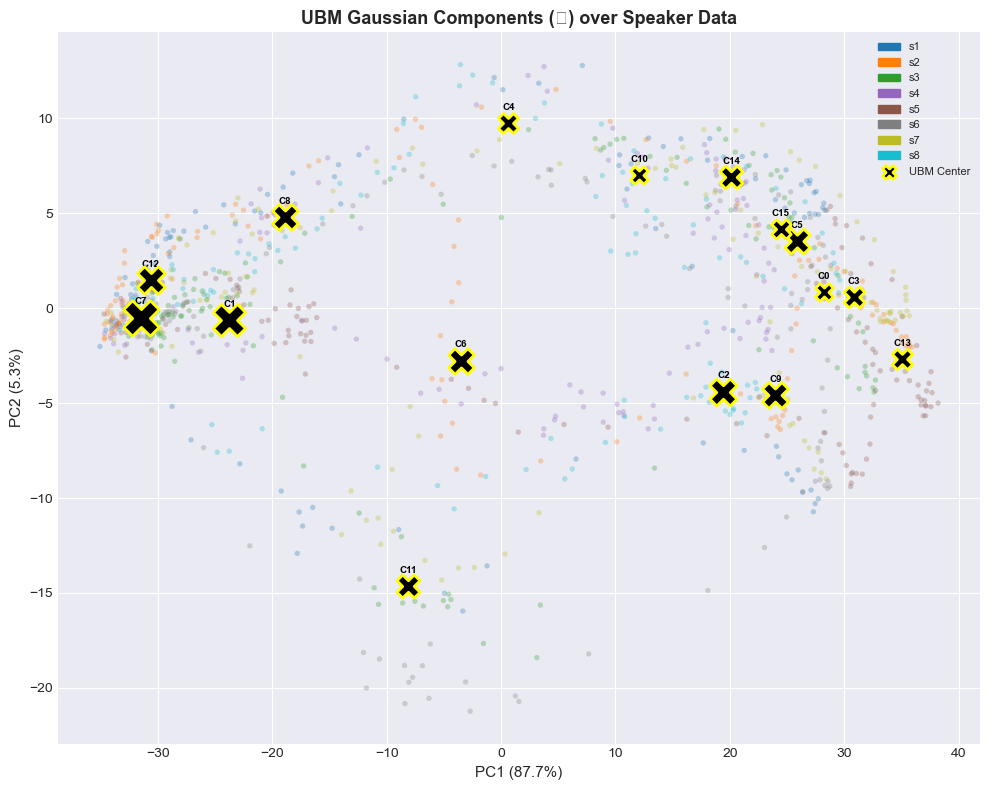

In [10]:
# ============================================================
#  Section 7: UBM Components in PCA Space
# ============================================================
# Project UBM means to 2D PCA
ubm_means_2d = pca.transform(scaler.inverse_transform(ubm.means_))

fig, ax = plt.subplots(figsize=(10, 8))

# Plot speaker data points
for spk, color in zip(speakers, colors):
    mask = all_train_labels == spk
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1], 
               c=[color], label=spk, alpha=0.3, s=15, edgecolors='none')

# Plot UBM component centers
for k in range(config.UBM_N_COMPONENTS):
    size = ubm.weights_[k] * 5000  # Size proportional to weight
    ax.scatter(ubm_means_2d[k, 0], ubm_means_2d[k, 1],
               c='black', marker='X', s=size, zorder=5, edgecolors='yellow', linewidth=2)
    ax.annotate(f'C{k}', (ubm_means_2d[k, 0], ubm_means_2d[k, 1]),
                fontsize=7, ha='center', va='bottom', fontweight='bold',
                color='black', xytext=(0, 8), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('UBM Gaussian Components (✕) over Speaker Data', fontsize=13, fontweight='bold')

# Legend
handles = [mpatches.Patch(color=c, label=s) for s, c in zip(speakers, colors)]
handles.append(plt.scatter([], [], marker='X', c='black', s=100, edgecolors='yellow', linewidth=2, label='UBM Center'))
ax.legend(handles=handles, loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## Section 8: MAP Adaptation — Speaker-Specific GMMs

For each speaker, we **adapt the UBM** using Maximum A Posteriori (MAP) estimation:

$$\hat{\mu}_k^{(s)} = \alpha_k \cdot \bar{x}_k^{(s)} + (1 - \alpha_k) \cdot \mu_k^{\text{UBM}}$$

where $\alpha_k = \frac{n_k}{n_k + r}$ and $r$ is the relevance factor.

This is more robust than training a separate GMM per speaker from scratch — the UBM acts as a **strong prior**.

In [11]:
# ============================================================
#  Section 8: MAP Adaptation
# ============================================================
def map_adapt_speaker(ubm, speaker_features_scaled, config):
    """MAP-adapt a UBM to a specific speaker. Returns adapted GMM."""
    posteriors = ubm.predict_proba(speaker_features_scaled)
    n_k = posteriors.sum(axis=0)
    F_k = posteriors.T @ speaker_features_scaled
    
    adapted_gmm = GaussianMixture(
        n_components=config.UBM_N_COMPONENTS,
        covariance_type=config.COVARIANCE_TYPE,
    )
    adapted_gmm.means_ = ubm.means_.copy()
    adapted_gmm.covariances_ = ubm.covariances_.copy()
    adapted_gmm.weights_ = ubm.weights_.copy()
    adapted_gmm.precisions_cholesky_ = ubm.precisions_cholesky_.copy()
    adapted_gmm.converged_ = True
    
    r = config.MAP_RELEVANCE_FACTOR
    alpha_values = []
    
    for k in range(config.UBM_N_COMPONENTS):
        alpha_k = n_k[k] / (n_k[k] + r)
        alpha_values.append(alpha_k)
        
        if config.MAP_ADAPT_MEANS and n_k[k] > 0:
            speaker_mean_k = F_k[k] / n_k[k]
            adapted_gmm.means_[k] = alpha_k * speaker_mean_k + (1 - alpha_k) * ubm.means_[k]
        
        if config.MAP_ADAPT_WEIGHTS and n_k[k] > 0:
            adapted_gmm.weights_[k] = (alpha_k * (n_k[k] / len(speaker_features_scaled)) + 
                                        (1 - alpha_k) * ubm.weights_[k])
    
    if config.MAP_ADAPT_WEIGHTS:
        adapted_gmm.weights_ /= adapted_gmm.weights_.sum()
    
    if config.COVARIANCE_TYPE == 'diag':
        adapted_gmm.precisions_cholesky_ = 1.0 / np.sqrt(adapted_gmm.covariances_)
    
    return adapted_gmm, np.array(alpha_values)

# Adapt for all speakers
speaker_gmms = {}
speaker_alphas = {}

print("MAP Adaptation Results:")
print(f"{'Speaker':<10} {'Frames':<10} {'Avg α':<10} {'Max α':<10}")
print("-" * 40)

for spk in speakers:
    spk_scaled = scaler.transform(train_data[spk])
    gmm, alphas = map_adapt_speaker(ubm, spk_scaled, config)
    speaker_gmms[spk] = gmm
    speaker_alphas[spk] = alphas
    print(f"{spk:<10} {train_data[spk].shape[0]:<10} {alphas.mean():<10.3f} {alphas.max():<10.3f}")

print(f"\n✓ All {len(speakers)} speaker models adapted!")

MAP Adaptation Results:
Speaker    Frames     Avg α      Max α     
----------------------------------------
s1         123        0.249      0.643     
s2         123        0.249      0.651     
s3         123        0.248      0.619     
s4         123        0.259      0.578     
s5         123        0.235      0.661     
s6         123        0.274      0.554     
s7         123        0.270      0.589     
s8         123        0.270      0.543     

✓ All 8 speaker models adapted!


## Section 9: Visualize Adaptation — How Much Did Each Speaker Shift the UBM?

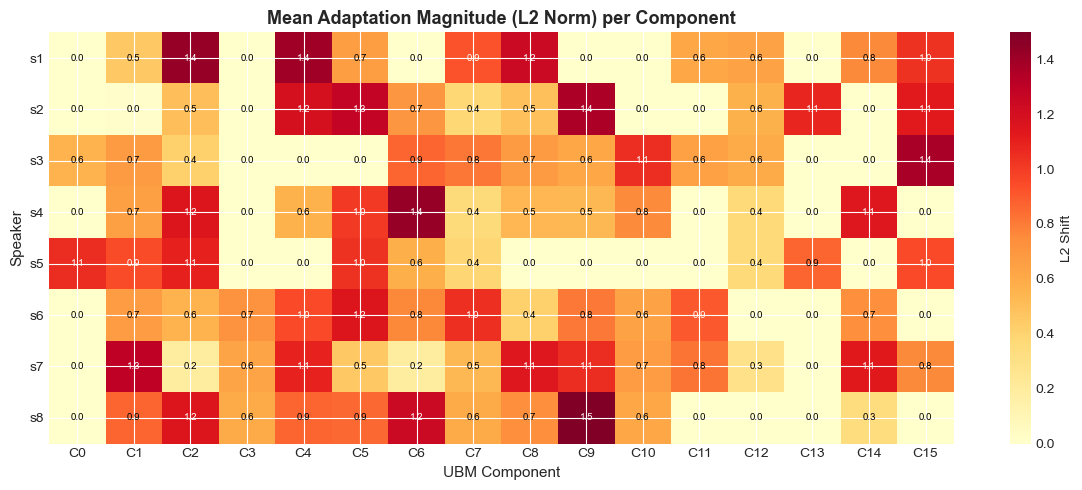

In [12]:
# ============================================================
#  Section 9a: Mean Shift Heatmap (L2 norm of UBM→Speaker adaptation)
# ============================================================
mean_shifts = np.zeros((len(speakers), config.UBM_N_COMPONENTS))
for i, spk in enumerate(speakers):
    for k in range(config.UBM_N_COMPONENTS):
        shift = np.linalg.norm(speaker_gmms[spk].means_[k] - ubm.means_[k])
        mean_shifts[i, k] = shift

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(mean_shifts, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(speakers)))
ax.set_yticklabels(speakers)
ax.set_xticks(range(config.UBM_N_COMPONENTS))
ax.set_xticklabels([f'C{k}' for k in range(config.UBM_N_COMPONENTS)])
ax.set_xlabel('UBM Component', fontsize=11)
ax.set_ylabel('Speaker', fontsize=11)
ax.set_title('Mean Adaptation Magnitude (L2 Norm) per Component', fontsize=13, fontweight='bold')

# Annotate cells
for i in range(len(speakers)):
    for j in range(config.UBM_N_COMPONENTS):
        ax.text(j, i, f'{mean_shifts[i, j]:.1f}', ha='center', va='center', 
                fontsize=7, color='black' if mean_shifts[i, j] < mean_shifts.max()*0.6 else 'white')

plt.colorbar(im, ax=ax, label='L2 Shift')
plt.tight_layout()
plt.show()

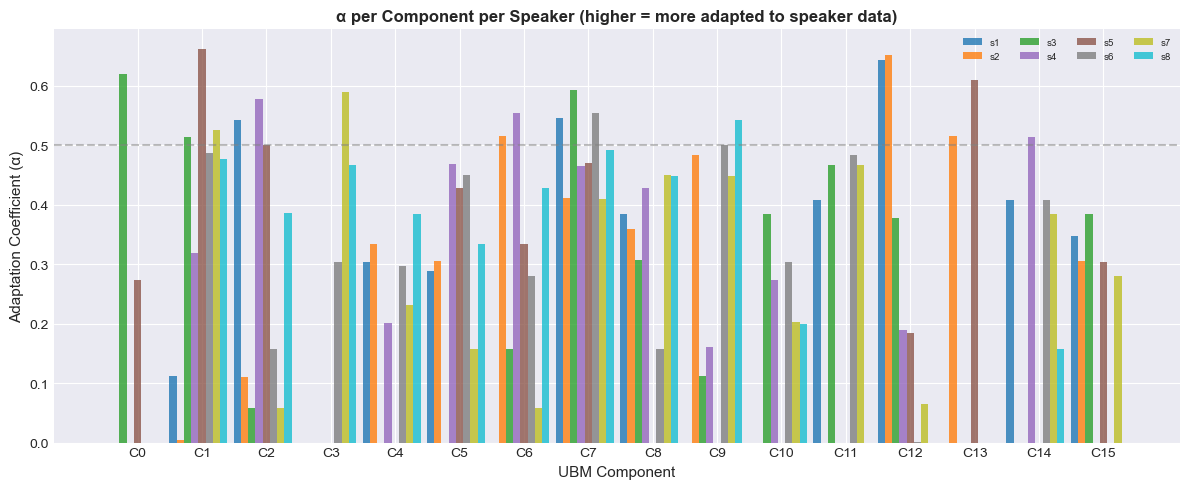

In [13]:
# ============================================================
#  Section 9b: Adaptation Coefficient α per Component
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(config.UBM_N_COMPONENTS)
width = 0.9 / len(speakers)

for i, (spk, color) in enumerate(zip(speakers, colors)):
    ax.bar(x + i * width, speaker_alphas[spk], width, label=spk, color=color, alpha=0.8)

ax.set_xlabel('UBM Component', fontsize=11)
ax.set_ylabel('Adaptation Coefficient (α)', fontsize=11)
ax.set_title('α per Component per Speaker (higher = more adapted to speaker data)', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * len(speakers) / 2)
ax.set_xticklabels([f'C{k}' for k in range(config.UBM_N_COMPONENTS)])
ax.legend(fontsize=7, ncol=4)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='α=0.5')
plt.tight_layout()
plt.show()

## Section 10: Score Matrix — Log-Likelihood Ratios

For each test utterance, we compute:

$$\text{score}(X, s) = \log P(X \mid \lambda_s) - \log P(X \mid \lambda_{\text{UBM}})$$

Positive score → the test audio is **more like speaker $s$ than general speech**.

In [14]:
# ============================================================
#  Section 10: Compute Score Matrix
# ============================================================
def score_utterance(features, ubm, speaker_gmms, scaler, speakers):
    """Score test features against all speaker models. Returns LLR dict."""
    feat_scaled = scaler.transform(features)
    ubm_score = ubm.score(feat_scaled)
    scores = {}
    for spk in speakers:
        scores[spk] = speaker_gmms[spk].score(feat_scaled) - ubm_score
    return scores

def identify(features, ubm, speaker_gmms, scaler, speakers):
    """Identify speaker: returns (predicted, confidence%, all_confidences, raw_scores)."""
    scores = score_utterance(features, ubm, speaker_gmms, scaler, speakers)
    predicted = max(scores, key=scores.get)
    
    score_vals = np.array([scores[s] for s in speakers])
    exp_scores = np.exp(score_vals - score_vals.max())
    confidences = exp_scores / exp_scores.sum()
    conf_dict = {s: c for s, c in zip(speakers, confidences)}
    
    return predicted, conf_dict[predicted], conf_dict, scores

# Build full score matrix
score_matrix = np.zeros((len(speakers), len(speakers)))
predictions = []
true_labels = []

print(f"{'True':<8} {'Predicted':<10} {'Confidence':<12} {'Correct':<8}")
print("-" * 45)

for i, true_spk in enumerate(speakers):
    pred, conf, all_conf, scores = identify(test_data[true_spk], ubm, speaker_gmms, scaler, speakers)
    predictions.append(pred)
    true_labels.append(true_spk)
    
    for j, enrolled_spk in enumerate(speakers):
        score_matrix[i, j] = scores[enrolled_spk]
    
    status = "✓" if pred == true_spk else "✗"
    print(f"{true_spk:<8} {pred:<10} {conf:<12.1%} {status}")

accuracy = sum(1 for t, p in zip(true_labels, predictions) if t == p) / len(true_labels)
print(f"\n{'='*45}")
print(f"ACCURACY: {accuracy:.1%}")
print(f"{'='*45}")

True     Predicted  Confidence   Correct 
---------------------------------------------
s1       s1         86.6%        ✓
s2       s2         90.3%        ✓
s3       s3         42.5%        ✓
s4       s4         65.7%        ✓
s5       s5         68.1%        ✓
s6       s6         38.4%        ✓
s7       s7         59.6%        ✓
s8       s8         52.4%        ✓

ACCURACY: 100.0%


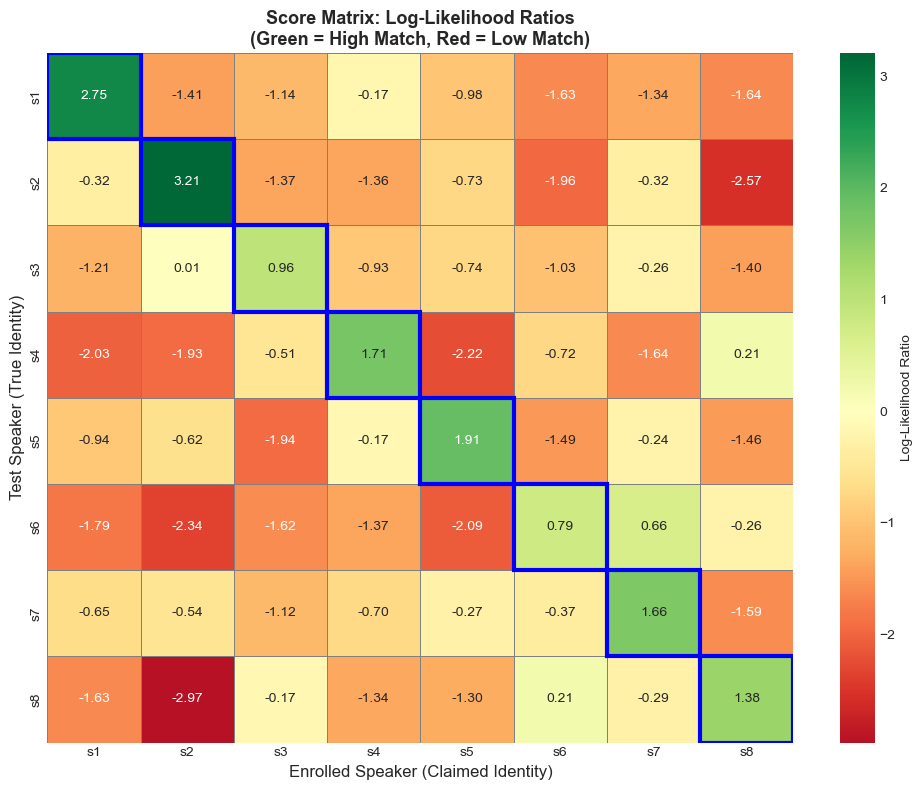

In [15]:
# ============================================================
#  Section 10b: Score Matrix Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))
im = sns.heatmap(score_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                  xticklabels=speakers, yticklabels=speakers, ax=ax,
                  linewidths=0.5, linecolor='gray',
                  cbar_kws={'label': 'Log-Likelihood Ratio'})

ax.set_xlabel('Enrolled Speaker (Claimed Identity)', fontsize=12)
ax.set_ylabel('Test Speaker (True Identity)', fontsize=12)
ax.set_title('Score Matrix: Log-Likelihood Ratios\n(Green = High Match, Red = Low Match)', 
             fontsize=13, fontweight='bold')

# Highlight diagonal
for i in range(len(speakers)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='blue', linewidth=3))

plt.tight_layout()
plt.show()

## Section 11–12: Confusion Matrix & Classification Report

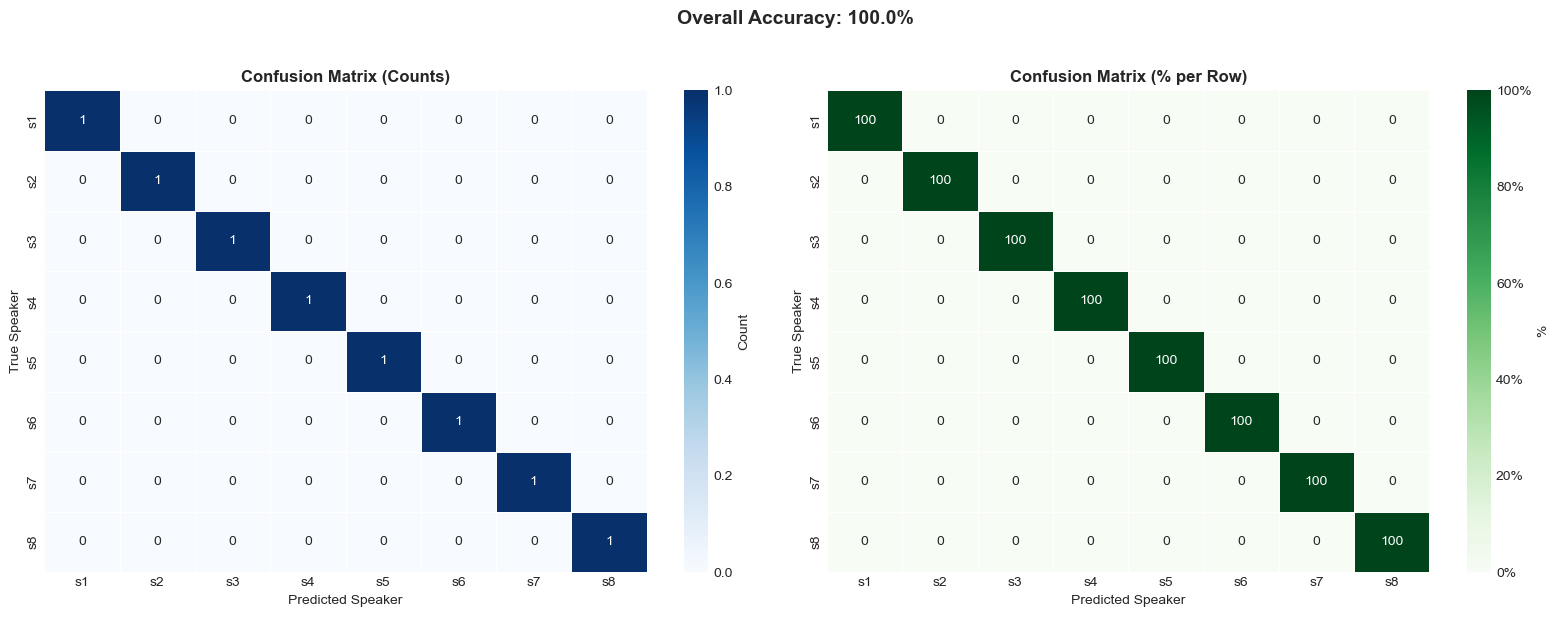


Classification Report:
              precision    recall  f1-score   support

          s1       1.00      1.00      1.00         1
          s2       1.00      1.00      1.00         1
          s3       1.00      1.00      1.00         1
          s4       1.00      1.00      1.00         1
          s5       1.00      1.00      1.00         1
          s6       1.00      1.00      1.00         1
          s7       1.00      1.00      1.00         1
          s8       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [16]:
# ============================================================
#  Section 12: Confusion Matrix
# ============================================================
cm = confusion_matrix(true_labels, predictions, labels=speakers)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=speakers, yticklabels=speakers,
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Speaker')
axes[0].set_ylabel('True Speaker')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Percentages (normalized by row)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.0f', cmap='Greens', xticklabels=speakers, yticklabels=speakers,
            ax=axes[1], linewidths=0.5, cbar_kws={'label': '%', 'format': '%.0f%%'}, vmin=0, vmax=100)
axes[1].set_xlabel('Predicted Speaker')
axes[1].set_ylabel('True Speaker')
axes[1].set_title('Confusion Matrix (% per Row)', fontweight='bold')

plt.suptitle(f'Overall Accuracy: {accuracy:.1%}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=speakers))

## Section 13: Per-Speaker Confidence Heatmap

Each cell shows how confident the system is that a test utterance belongs to each enrolled speaker (softmax over LLR scores).

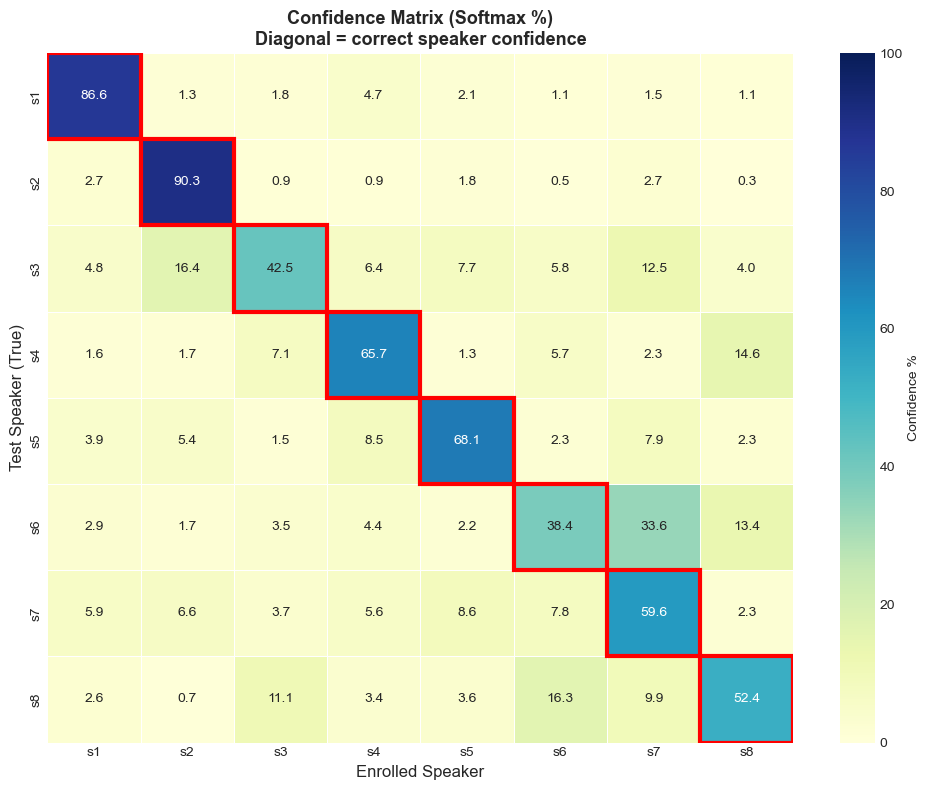

In [17]:
# ============================================================
#  Section 13: Confidence Heatmap
# ============================================================
conf_matrix = np.zeros((len(speakers), len(speakers)))
for i, true_spk in enumerate(speakers):
    _, _, all_conf, _ = identify(test_data[true_spk], ubm, speaker_gmms, scaler, speakers)
    for j, enrolled_spk in enumerate(speakers):
        conf_matrix[i, j] = all_conf[enrolled_spk]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(conf_matrix * 100, annot=True, fmt='.1f', cmap='YlGnBu',
            xticklabels=speakers, yticklabels=speakers, ax=ax,
            linewidths=0.5, vmin=0, vmax=100, cbar_kws={'label': 'Confidence %'})

ax.set_xlabel('Enrolled Speaker', fontsize=12)
ax.set_ylabel('Test Speaker (True)', fontsize=12)
ax.set_title('Confidence Matrix (Softmax %)\nDiagonal = correct speaker confidence', 
             fontsize=13, fontweight='bold')

# Highlight diagonal
for i in range(len(speakers)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='red', linewidth=3))

plt.tight_layout()
plt.show()

## Section 14: Genuine vs Impostor Score Distributions & EER

- **Genuine scores**: when test speaker = enrolled speaker (diagonal of score matrix)
- **Impostor scores**: when test speaker ≠ enrolled speaker (off-diagonal)

The **Equal Error Rate (EER)** is the threshold where False Accept Rate = False Reject Rate.

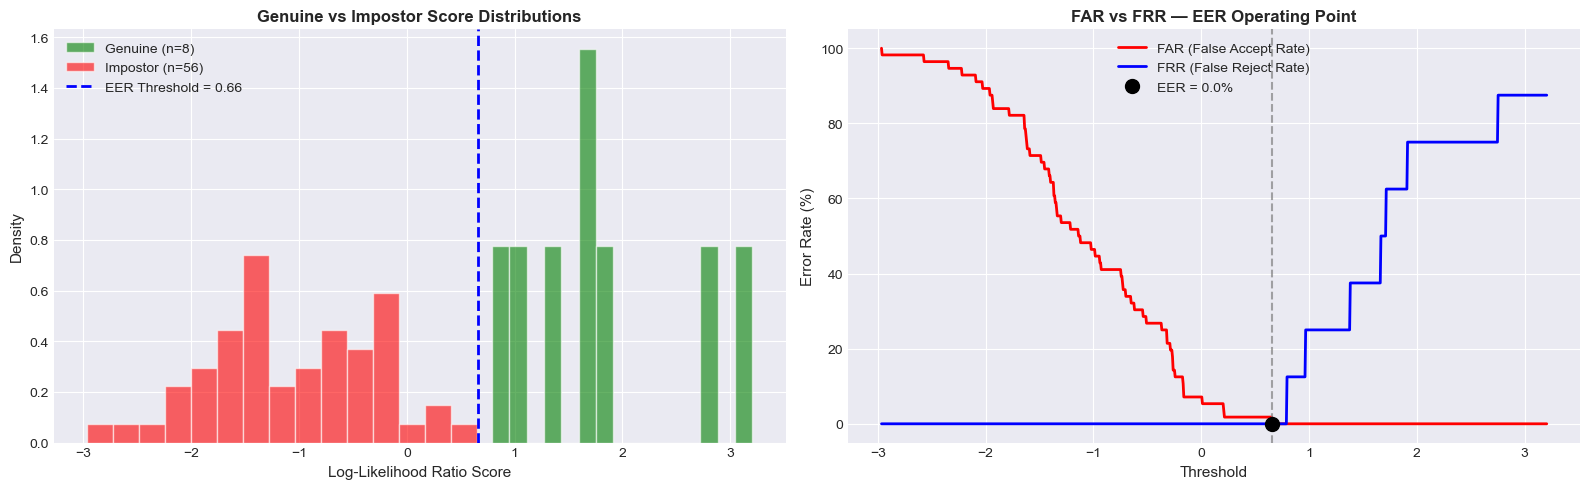

Equal Error Rate (EER): 0.00%
EER Threshold: 0.660
Genuine scores: mean=1.80, std=0.78
Impostor scores: mean=-1.07, std=0.76


In [18]:
# ============================================================
#  Section 14: Genuine vs Impostor Scores + EER
# ============================================================
genuine_scores = []
impostor_scores = []

for i, true_spk in enumerate(speakers):
    for j, enrolled_spk in enumerate(speakers):
        if true_spk == enrolled_spk:
            genuine_scores.append(score_matrix[i, j])
        else:
            impostor_scores.append(score_matrix[i, j])

genuine_scores = np.array(genuine_scores)
impostor_scores = np.array(impostor_scores)

# Compute EER
thresholds = np.linspace(min(impostor_scores.min(), genuine_scores.min()),
                          max(impostor_scores.max(), genuine_scores.max()), 1000)
far = np.array([np.mean(impostor_scores >= t) for t in thresholds])  # False Accept
frr = np.array([np.mean(genuine_scores < t) for t in thresholds])     # False Reject
eer_idx = np.argmin(np.abs(far - frr))
eer = (far[eer_idx] + frr[eer_idx]) / 2
eer_threshold = thresholds[eer_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution plot
ax = axes[0]
ax.hist(genuine_scores, bins=15, alpha=0.6, color='green', label=f'Genuine (n={len(genuine_scores)})', density=True, edgecolor='white')
ax.hist(impostor_scores, bins=15, alpha=0.6, color='red', label=f'Impostor (n={len(impostor_scores)})', density=True, edgecolor='white')
ax.axvline(x=eer_threshold, color='blue', linestyle='--', linewidth=2, label=f'EER Threshold = {eer_threshold:.2f}')
ax.set_xlabel('Log-Likelihood Ratio Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Genuine vs Impostor Score Distributions', fontsize=12, fontweight='bold')
ax.legend()

# FAR/FRR curve
ax2 = axes[1]
ax2.plot(thresholds, far * 100, 'r-', linewidth=2, label='FAR (False Accept Rate)')
ax2.plot(thresholds, frr * 100, 'b-', linewidth=2, label='FRR (False Reject Rate)')
ax2.axvline(x=eer_threshold, color='gray', linestyle='--', alpha=0.7)
ax2.plot(eer_threshold, eer * 100, 'ko', markersize=10, zorder=5, label=f'EER = {eer:.1%}')
ax2.set_xlabel('Threshold', fontsize=11)
ax2.set_ylabel('Error Rate (%)', fontsize=11)
ax2.set_title('FAR vs FRR — EER Operating Point', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Equal Error Rate (EER): {eer:.2%}")
print(f"EER Threshold: {eer_threshold:.3f}")
print(f"Genuine scores: mean={genuine_scores.mean():.2f}, std={genuine_scores.std():.2f}")
print(f"Impostor scores: mean={impostor_scores.mean():.2f}, std={impostor_scores.std():.2f}")

## Section 15: ROC Curve

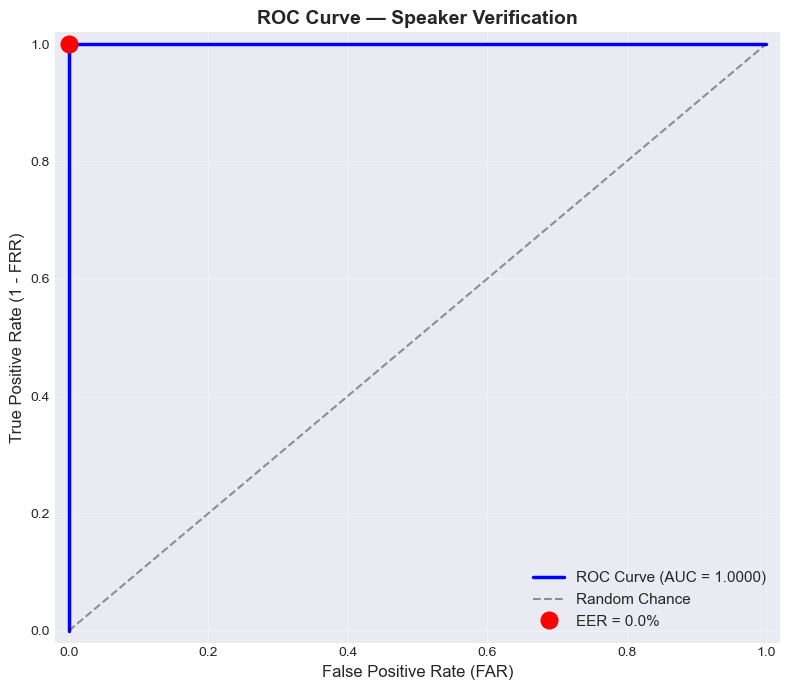

AUC: 1.0000


In [19]:
# ============================================================
#  Section 15: ROC Curve
# ============================================================
from sklearn.metrics import roc_curve, auc

# Binary labels: 1=genuine, 0=impostor
y_true = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])
y_scores = np.concatenate([genuine_scores, impostor_scores])

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Chance')

# Mark EER point on ROC
eer_fpr = far[eer_idx]
eer_tpr = 1 - frr[eer_idx]
ax.plot(eer_fpr, eer_tpr, 'ro', markersize=12, zorder=5, label=f'EER = {eer:.1%}')

ax.set_xlabel('False Positive Rate (FAR)', fontsize=12)
ax.set_ylabel('True Positive Rate (1 - FRR)', fontsize=12)
ax.set_title('ROC Curve — Speaker Verification', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")

## Section 16: Single Utterance Test Pipeline

This is how you test a **single .mat file** (exported from MATLAB) or use a numpy array directly.

### How to use `test_pipeline.py` from the terminal:
```bash
# From the Final/ directory:
python test_pipeline.py
```
This extracts MFCCs from the .wav files directly using `librosa` (Python) and runs the full train + evaluate cycle without needing MATLAB.

Test file: exported_features/test/s3_mfcc.mat
Predicted: s3 (confidence: 42.5%)
Frames: 123, Features: 39


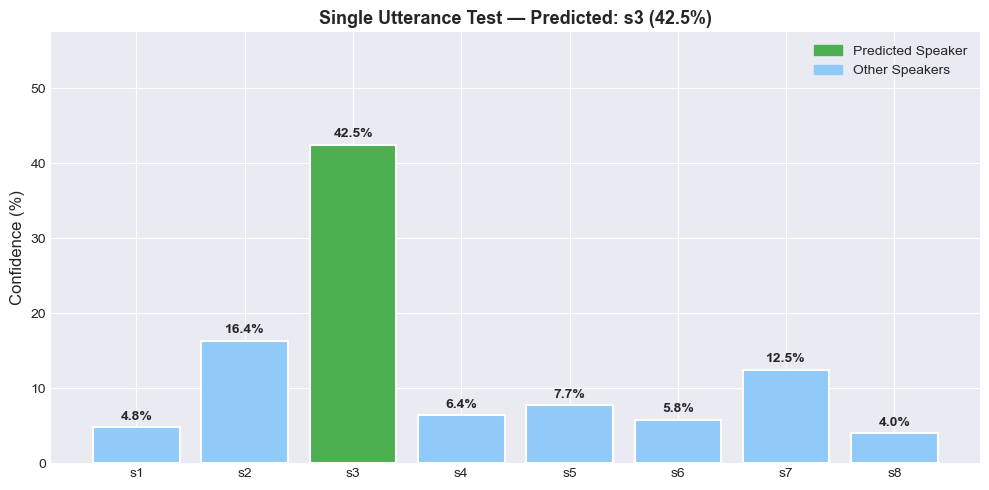

In [20]:
# ============================================================
#  Section 16: Single Utterance Identification (from .mat file)
# ============================================================
def test_single_mat(mat_path, ubm, speaker_gmms, scaler, speakers):
    """Load a .mat file and identify the speaker."""
    data = sio.loadmat(mat_path)
    
    # Handle MATLAB orientation
    if 'mfcc_coeffs' in data and 'delta_mfcc' in data and 'delta2_mfcc' in data:
        features = np.hstack([data['mfcc_coeffs'].T, data['delta_mfcc'].T, data['delta2_mfcc'].T])
    elif 'mfcc_coeffs' in data and 'delta_coeffs' in data and 'delta2_coeffs' in data:
        features = np.hstack([data['mfcc_coeffs'].T, data['delta_coeffs'].T, data['delta2_coeffs'].T])
    else:
        features = data['features']
        if features.shape[0] < features.shape[1]:
            features = features.T
    
    pred, conf, all_conf, scores = identify(features, ubm, speaker_gmms, scaler, speakers)
    return pred, conf, all_conf, scores, features

# ---- DEMO: Test with one file ----
test_file = "exported_features/test/s3_mfcc.mat"
if os.path.exists(test_file):
    pred, conf, all_conf, scores, feat = test_single_mat(test_file, ubm, speaker_gmms, scaler, speakers)
    
    print(f"Test file: {test_file}")
    print(f"Predicted: {pred} (confidence: {conf:.1%})")
    print(f"Frames: {feat.shape[0]}, Features: {feat.shape[1]}")
    
    # Bar chart of confidence
    fig, ax = plt.subplots(figsize=(10, 5))
    conf_vals = [all_conf[s] * 100 for s in speakers]
    bar_colors = ['#4CAF50' if s == pred else '#90CAF9' for s in speakers]
    bars = ax.bar(speakers, conf_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
    
    for bar, val in zip(bars, conf_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Confidence (%)', fontsize=12)
    ax.set_title(f'Single Utterance Test — Predicted: {pred} ({conf:.1%})', fontsize=13, fontweight='bold')
    ax.set_ylim(0, max(conf_vals) + 15)
    
    # Legend
    ax.legend([mpatches.Patch(color='#4CAF50'), mpatches.Patch(color='#90CAF9')],
              ['Predicted Speaker', 'Other Speakers'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠ File not found: {test_file}")

## Section 17: Identify Speaker from Audio File (.wav)

This uses `librosa` to extract MFCCs in Python — **no MATLAB needed at inference time**.

### How to use `identify_speaker.py` from the terminal:
```bash
# Identify from a .wav file:
python identify_speaker.py --audio path/to/audio.wav

# Identify from a MATLAB .mat file:
python identify_speaker.py --mat exported_features/test/s3_mfcc.mat

# Record from microphone (3 seconds) and identify:
python identify_speaker.py --record --duration 3
```

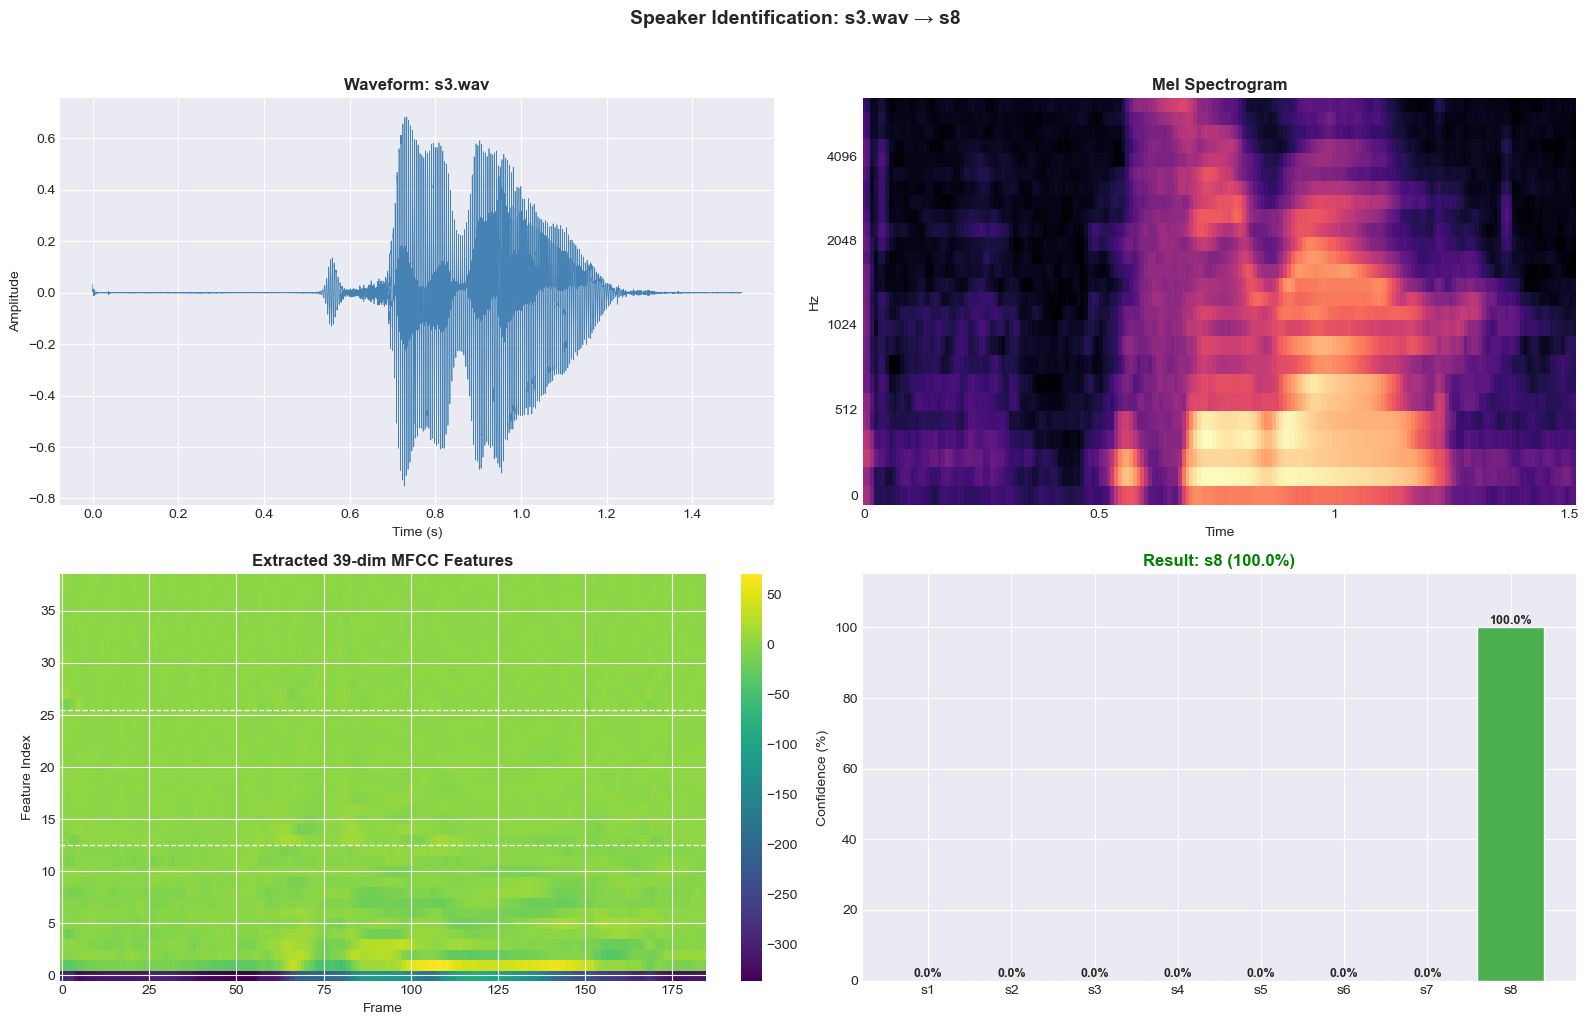

In [22]:
# ============================================================
#  Section 17: Identify from Audio (.wav) using librosa
# ============================================================
def extract_mfcc_python(audio, sr, n_mfcc=13, n_fft=512, hop_length=100,
                         n_mels=26, pre_emphasis=0.97):
    """Extract 39-dim MFCC features matching our MATLAB pipeline using librosa."""
    if not HAS_LIBROSA:
        raise ImportError("librosa required! Install: pip install librosa")
    
    # Pre-emphasis
    audio_emph = np.append(audio[0], audio[1:] - pre_emphasis * audio[:-1])
    
    # MFCC extraction (librosa does framing, windowing, FFT, mel, log, DCT internally)
    mfcc_coeffs = librosa.feature.mfcc(
        y=audio_emph, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft,
        hop_length=hop_length, n_mels=n_mels,
        fmax=sr // 2, window='hamming', center=False
    ).T  # → (frames × 13)
    
    # Delta and Delta-Delta
    delta = librosa.feature.delta(mfcc_coeffs.T, width=5).T
    delta2 = librosa.feature.delta(mfcc_coeffs.T, width=5, order=2).T
    
    return np.hstack([mfcc_coeffs, delta, delta2])  # (frames × 39)

def identify_from_wav(wav_path, ubm, speaker_gmms, scaler, speakers):
    """Full pipeline: wav → MFCCs → identification."""
    audio, sr = librosa.load(wav_path, sr=None)
    features = extract_mfcc_python(audio, sr)
    pred, conf, all_conf, scores = identify(features, ubm, speaker_gmms, scaler, speakers)
    return pred, conf, all_conf, scores, audio, sr, features

# ---- DEMO: Test with a wav file ----
test_wav = "data/test/s3.wav"
if os.path.exists(test_wav) and HAS_LIBROSA:
    pred, conf, all_conf, scores, audio, sr, feat = identify_from_wav(
        test_wav, ubm, speaker_gmms, scaler, speakers)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Waveform
    ax = axes[0, 0]
    t = np.arange(len(audio)) / sr
    ax.plot(t, audio, color='steelblue', linewidth=0.5)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Waveform: {os.path.basename(test_wav)}', fontweight='bold')
    
    # 2. Spectrogram
    ax = axes[0, 1]
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=26, n_fft=512, hop_length=100)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=100, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title('Mel Spectrogram', fontweight='bold')
    
    # 3. MFCC Heatmap
    ax = axes[1, 0]
    im = ax.imshow(feat.T, aspect='auto', origin='lower', cmap='viridis')
    ax.axhline(y=12.5, color='white', linestyle='--', linewidth=1)
    ax.axhline(y=25.5, color='white', linestyle='--', linewidth=1)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Feature Index')
    ax.set_title('Extracted 39-dim MFCC Features', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 4. Confidence bar chart
    ax = axes[1, 1]
    conf_vals = [all_conf[s] * 100 for s in speakers]
    bar_colors = ['#4CAF50' if s == pred else '#BBDEFB' for s in speakers]
    bars = ax.bar(speakers, conf_vals, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, conf_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Confidence (%)')
    ax.set_title(f'Result: {pred} ({conf:.1%})', fontweight='bold', color='green')
    ax.set_ylim(0, max(conf_vals) + 15)
    
    plt.suptitle(f'Speaker Identification: {os.path.basename(test_wav)} → {pred}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ librosa or test wav not available. Use .mat files instead.")

## Section 18: Save & Load Models

Save the entire trained system as a single `.pkl` file for deployment.

In [25]:
# ============================================================
#  Section 18: Save & Load Models
# ============================================================
os.makedirs(config.MODEL_DIR, exist_ok=True)

model_data = {
    'ubm': ubm,
    'speaker_gmms': speaker_gmms,
    'scaler': scaler,
    'speaker_list': speakers,
    'config': config
}

model_path = os.path.join(config.MODEL_DIR, 'gmm_ubm_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

file_size = os.path.getsize(model_path)
print(f"✓ Model saved to: {model_path}")
print(f"✓ File size: {file_size / 1024:.1f} KB")
print(f"✓ Contents: UBM ({config.UBM_N_COMPONENTS} components), "
      f"{len(speakers)} speaker GMMs, scaler, config")

# Verify by loading back
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)
print(f"\n✓ Verification: loaded {len(loaded['speaker_list'])} speakers: {loaded['speaker_list']}")

# Quick verify scores match
test_feats = scaler.transform(test_data[speakers[0]])
orig_score = ubm.score(test_feats)
load_score = loaded['ubm'].score(test_feats)
print(f"✓ Score match: original={orig_score:.4f}, loaded={load_score:.4f}, match={np.isclose(orig_score, load_score)}")

✓ Model saved to: trained_models\gmm_ubm_model.pkl
✓ File size: 141.9 KB
✓ Contents: UBM (16 components), 8 speaker GMMs, scaler, config

✓ Verification: loaded 8 speakers: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
✓ Score match: original=-34.5628, loaded=-34.5628, match=True


## Section 19: Hyperparameter Tuning

Grid search over:
- **UBM Components**: 8, 16, 32, 64
- **MAP Relevance Factor**: 4, 8, 16, 32

⚠️ This cell takes a minute to run since it trains multiple models.

  Training: n_components=8, relevance=4 ... Accuracy = 100.0%
  Training: n_components=8, relevance=8 ... Accuracy = 100.0%
  Training: n_components=8, relevance=16 ... Accuracy = 100.0%
  Training: n_components=8, relevance=32 ... Accuracy = 100.0%
  Training: n_components=16, relevance=4 ... Accuracy = 87.5%
  Training: n_components=16, relevance=8 ... Accuracy = 87.5%
  Training: n_components=16, relevance=16 ... Accuracy = 100.0%
  Training: n_components=16, relevance=32 ... Accuracy = 100.0%
  Training: n_components=32, relevance=4 ... Accuracy = 100.0%
  Training: n_components=32, relevance=8 ... Accuracy = 100.0%
  Training: n_components=32, relevance=16 ... Accuracy = 100.0%
  Training: n_components=32, relevance=32 ... Accuracy = 100.0%
  Training: n_components=64, relevance=4 ... Accuracy = 100.0%
  Training: n_components=64, relevance=8 ... Accuracy = 100.0%
  Training: n_components=64, relevance=16 ... Accuracy = 100.0%
  Training: n_components=64, relevance=32 ... Accuracy

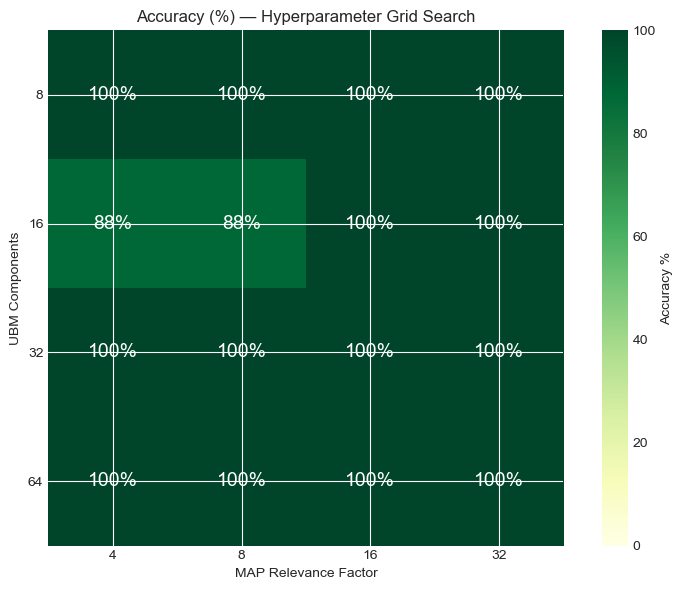


✅ Best: n_components=8, relevance_factor=4, accuracy=100.0%


In [26]:
# ============================================================
# Section 19 — Hyperparameter Tuning (Grid Search)
# ============================================================
comp_values = [8, 16, 32, 64]
rel_values  = [4, 8, 16, 32]

results = np.zeros((len(comp_values), len(rel_values)))

for i, n_comp in enumerate(comp_values):
    for j, rel_f in enumerate(rel_values):
        print(f"  Training: n_components={n_comp}, relevance={rel_f} ... ", end="")

        # --- build a temporary system ---
        ubm_tmp = GaussianMixture(
            n_components=n_comp, covariance_type='diag',
            max_iter=200, n_init=3, random_state=42
        )
        ubm_tmp.fit(all_train_scaled)

        adapted_tmp = {}
        for spk, feats in train_data.items():
            feats_sc = scaler.transform(feats)
            resp = ubm_tmp.predict_proba(feats_sc)
            n_k = resp.sum(axis=0)
            adapted_means = ubm_tmp.means_.copy()
            adapted_weights = ubm_tmp.weights_.copy()
            for k in range(n_comp):
                if n_k[k] > 0:
                    x_k = (resp[:, k:k+1] * feats_sc).sum(axis=0) / n_k[k]
                    alpha_k = n_k[k] / (n_k[k] + rel_f)
                    adapted_means[k] = alpha_k * x_k + (1 - alpha_k) * ubm_tmp.means_[k]
                    adapted_weights[k] = alpha_k * (n_k[k] / len(feats_sc)) + (1 - alpha_k) * ubm_tmp.weights_[k]
            adapted_weights /= adapted_weights.sum()
            gm = GaussianMixture(n_components=n_comp, covariance_type='diag')
            gm.means_ = adapted_means
            gm.covariances_ = ubm_tmp.covariances_.copy()
            gm.weights_ = adapted_weights
            gm.precisions_cholesky_ = ubm_tmp.precisions_cholesky_.copy()
            adapted_tmp[spk] = gm

        # evaluate
        correct = 0
        total   = 0
        for spk, feats in test_data.items():
            feats_sc = scaler.transform(feats)
            ubm_ll = ubm_tmp.score(feats_sc) * len(feats_sc)
            scores = {}
            for s, gm in adapted_tmp.items():
                scores[s] = gm.score(feats_sc) * len(feats_sc) - ubm_ll
            pred = max(scores, key=scores.get)
            if pred == spk:
                correct += 1
            total += 1

        acc = correct / total * 100
        results[i, j] = acc
        print(f"Accuracy = {acc:.1f}%")

# --- heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(results, cmap='YlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(rel_values)))
ax.set_xticklabels(rel_values)
ax.set_yticks(range(len(comp_values)))
ax.set_yticklabels(comp_values)
ax.set_xlabel('MAP Relevance Factor')
ax.set_ylabel('UBM Components')
ax.set_title('Accuracy (%) — Hyperparameter Grid Search')
for ii in range(len(comp_values)):
    for jj in range(len(rel_values)):
        ax.text(jj, ii, f"{results[ii,jj]:.0f}%",
                ha='center', va='center', fontsize=14,
                color='white' if results[ii,jj] > 60 else 'black')
fig.colorbar(im, ax=ax, label='Accuracy %')
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(results.argmax(), results.shape)
print(f"\n✅ Best: n_components={comp_values[best_idx[0]]}, "
      f"relevance_factor={rel_values[best_idx[1]]}, "
      f"accuracy={results[best_idx]:.1f}%")

---

## How to Use the Companion Scripts

### 1. `test_pipeline.py` — End-to-End Validation
Runs the full pipeline from `.wav` files using **librosa** for MFCC extraction (no MATLAB needed).

```bash
cd Final
python test_pipeline.py
```

It will:
- Load all train/test `.wav` files from `data/train/` and `data/test/`
- Extract 39-dim MFCC features via librosa
- Train UBM → MAP-adapt per speaker → score test utterances
- Print per-speaker results + overall accuracy

---

### 2. `identify_speaker.py` — Real-Time Inference
Identify a speaker from a `.wav` file, a `.mat` file, or live microphone input.

```bash
# From a .wav file
python identify_speaker.py --audio data/test/s3.wav

# From a MATLAB .mat file
python identify_speaker.py --mat exported_features/test/s3_mfcc.mat

# Record from microphone (3 seconds)
python identify_speaker.py --record --duration 3
```

It loads saved models from `trained_models/` (created by Section 18 above) and prints the predicted speaker with confidence percentage.

> **Note:** Both scripts must be run from the `Final/` directory so relative paths resolve correctly.